# Case Study: Does the Lopez-Salido, Stein & Zakrajsek (2017) Sentiment Signal Speak to the 2020-2022 Cycle?
## Introduction

**What is this notebook doing?** It takes the Lopez-Salido, Stein
& Zakrajšek (2017, "LSZ") credit-market sentiment
first stage, estimated on 1929-2015, and applies it, unchanged, to the
COVID cycle. The 2020-2021 period looked like the configuration LSZ call
elevated sentiment. Right after the Fed's March-2020 backstop, the Baa-Treasury
spread compressed sharply and high-yield issuance surged. Their mechanism says
that froth predicts a subsequent widening of spreads (and a slowdown), as
credit conditions mean-revert. The question this notebook asks is simple:
**pointed at 2020-2022, which way does the signal lean, and does it match what
happened?**

| # | Section | What it shows |
|---|---|---|
| 1 | The LSZ first stage on 1929-2015 | The replication of the sentiment engine seen in previous notebooks |
| 2 | Coverage of the froth variable | How far the spliced high-yield share now extends |
| 3 | Out-of-sample probe, 2020-2022 | Full-sentiment vs. spread-only prediction of $\Delta s_t$, scored against realized spread changes |
| 4 | What we can and cannot conclude | Splice, sample-size, and generated-regressor caveats |

The verdict is computed below, not asserted here. With a three-year window
this is an illustrative probe, not a formal test, and the caveats in Section 4
bound how much weight it can carry.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent / "src"))
import plot_style as ps
import replicate_table_2 as t2
from settings import config

OUTPUT_DIR = Path(config("OUTPUT_DIR"))

# Annual panel (Baa spread), 1929 through the extension endpoint. Same builder
# the Table II replication uses, so the case study inherits the exact series
# and lag conventions.
df = t2.build_panel(spread_col="BAA_Treasury_spread")

hy = df["ln_hys"].dropna()
print(f"Panel years : {int(df.index.min())}-{int(df.index.max())}")
print(
    f"ln_hys span : {int(hy.index.min())}-{int(hy.index.max())}  ({hy.notna().sum()} years observed)"
)

Panel years : 1929-2025
ln_hys span : 1929-2025  (96 years observed)


## 1. The LSZ First Stage, Replicated on 1929-2015

Table II's first stage forecasts the change in the credit spread from
the twice-lagged sentiment:

$$\Delta s_t = a_0 + a_1 \ln(\mathrm{HYS})_{t-2} + a_2\, s_{t-2} + u_t.$$

The LSZ signs are $a_1 > 0$ (a high past issuance share predicts the spread
widening) and $a_2 < 0$ (a wide spread mean-reverts). We fit it on the
replication sample and read the coefficients off, before applying them out of
sample.

In [2]:
res = t2.run_table_2(df)  # fit on the 1929-2015 replication window
aux = res["aux_spread"]
c = aux.params

print("First-stage  Δs_t = a0 + a1·lnHYS_{t-2} + a2·s_{t-2}   (fit 1929-2015)")
for k in ["const", "ln_hys_lag2", "spread_lag2"]:
    print(f"  {k:>12}: {c[k]:+.4f}   (p = {aux.pvalues[k]:.3f})")

s1 = (
    "high issuance share predicts widening (LSZ sign)"
    if c["ln_hys_lag2"] > 0
    else "UNEXPECTED sign"
)
s2 = (
    "wide spread mean-reverts (LSZ sign)" if c["spread_lag2"] < 0 else "UNEXPECTED sign"
)
print(f"\n  a1 (froth)  {c['ln_hys_lag2']:+.3f}  ->  {s1}")
print(f"  a2 (level)  {c['spread_lag2']:+.3f}  ->  {s2}")

First-stage  Δs_t = a0 + a1·lnHYS_{t-2} + a2·s_{t-2}   (fit 1929-2015)
         const: +0.8125   (p = 0.000)
   ln_hys_lag2: +0.1474   (p = 0.000)
   spread_lag2: -0.2448   (p = 0.000)

  a1 (froth)  +0.147  ->  high issuance share predicts widening (LSZ sign)
  a2 (level)  -0.245  ->  wide spread mean-reverts (LSZ sign)


Both signs reproduce the paper's mechanism: the sentiment engine works on the
historical sample. The rest of the notebook holds this 1929-2015 fit fixed
and asks what it says about years it never saw.

## 2. The Froth Variable Now Reaches Past 2008

The hand-transcribed Greenwood-Hanson high-yield share ends in 2008. We
reconstructed the share from Mergent FISD (via WRDS) for later years and
spliced it onto the historical series, so the series `t2.build_panel` reads is now continuous through
the recent past. That extension is precisely what lets us form the full
two-ingredient sentiment prediction for the COVID window rather than the
spread-reversion leg alone.

In [3]:
last_hys = int(df["ln_hys"].dropna().index.max())
recent = df.loc[2016:2023, ["ln_hys_lag2", "spread_lag2", "d_spread", "dy"]].round(3)
print(recent)

# Predicting Δs_t needs lnHYS_{t-2}; so the full signal is available for year t
# whenever the froth variable exists at t-2.
covid_years = [y for y in (2020, 2021, 2022) if y in df.index]
full_ok = [yr for yr in covid_years if pd.notna(df.loc[yr, "ln_hys_lag2"])]
print(f"\nLast year with a high-yield-share observation: {last_hys}")
print(f"COVID years with a full-sentiment prediction available: {full_ok or 'none'}")

      ln_hys_lag2  spread_lag2  d_spread     dy
year                                           
2016       -0.884         2.53     -0.88  1.031
2017       -1.267         3.22     -0.52  1.737
2018       -1.306         2.34      0.48  2.333
2019       -1.224         1.82     -0.28  2.030
2020       -1.612         2.30      0.21 -2.504
2021       -1.363         2.02     -0.40  5.771
2022       -1.581         2.23      0.14  1.939
2023       -1.220         1.83     -0.35  2.077

Last year with a high-yield-share observation: 2025
COVID years with a full-sentiment prediction available: [2020, 2021, 2022]


## 3. Out-of-Sample Probe: 2020-2022

We take the first-stage coefficients fit on 1929-2015 and, without re-fitting,
form the predicted spread change for each COVID year:

$$\widehat{\Delta s_t} = a_0 + a_1 \ln(\mathrm{HYS})_{t-2} + a_2\, s_{t-2}.$$

We report two versions side by side: the **full sentiment** prediction (both
ingredients) and the **spread-reversion leg only** ($a_0 + a_2 s_{t-2}$). The
test is directional: does the sign of the predicted change match the sign of
the realized change?

In [4]:
def predict_dspread(year, coeffs, use_froth):
    # Predicted change in the spread from the fixed 1929-2015 first stage.
    # use_froth=True adds the lnHYS_{t-2} term; if that value is missing, the
    # full-sentiment prediction is undefined (NaN) for the year.
    pred = coeffs["const"] + coeffs["spread_lag2"] * df.loc[year, "spread_lag2"]
    if use_froth:
        h = df.loc[year, "ln_hys_lag2"]
        if pd.isna(h):
            return np.nan
        pred = pred + coeffs["ln_hys_lag2"] * h
    return pred


rows = []
for yr in covid_years:
    rows.append(
        {
            "year": yr,
            "s_(t-2)": round(df.loc[yr, "spread_lag2"], 2),
            "lnHYS_(t-2)": (
                round(df.loc[yr, "ln_hys_lag2"], 3)
                if pd.notna(df.loc[yr, "ln_hys_lag2"])
                else np.nan
            ),
            "pred_full": round(predict_dspread(yr, c, True), 3)
            if pd.notna(predict_dspread(yr, c, True))
            else np.nan,
            "pred_spread_only": round(predict_dspread(yr, c, False), 3),
            "actual_dS": round(df.loc[yr, "d_spread"], 3),
        }
    )
scorecard = pd.DataFrame(rows).set_index("year")
print(scorecard)


def hit_rate(col):
    ok = n = 0
    for yr in covid_years:
        p, a = scorecard.loc[yr, col], scorecard.loc[yr, "actual_dS"]
        if pd.notna(p) and pd.notna(a):
            n += 1
            ok += int(np.sign(p) == np.sign(a))
    return ok, n


print()
for col, label in [
    ("pred_full", "full sentiment (froth + reversion)"),
    ("pred_spread_only", "spread-reversion leg only"),
]:
    ok, n = hit_rate(col)
    verdict = (
        f"correct direction in {ok}/{n} years"
        if n
        else "no usable years (froth variable missing in window)"
    )
    print(f"  {label:>34}: {verdict}")

      s_(t-2)  lnHYS_(t-2)  pred_full  pred_spread_only  actual_dS
year                                                              
2020     2.30       -1.612      0.012             0.249       0.21
2021     2.02       -1.363      0.117             0.318      -0.40
2022     2.23       -1.581      0.034             0.267       0.14

  full sentiment (froth + reversion): correct direction in 2/3 years
           spread-reversion leg only: correct direction in 2/3 years


**How to read the scorecard?**

Each row scores one COVID-window year by comparing a predicted change in
the Baa-Treasury spread against what actually happened, and a row "hits"
when the two share a sign: a predicted widening ($\widehat{\Delta s_t}>0$)
paired with a realized widening, or a predicted narrowing paired with a
realized narrowing. Signs are the whole test here, because the LSZ mechanism
is a sign prediction - elevated sentiment two years earlier should show up as
spreads moving wider (credit getting more expensive), which is the leading
edge of the slowdown the paper documents. The size of the predicted number is
not meant to match the size of the realized one; only its direction is.

Walking through the three rows:

- **2020 - hit.** The model predicts a small widening (`pred_full` = +0.012)
  and the spread does widen (`actual_dS` = +0.21). The predicted move is an
  order of magnitude smaller than what happened, which is expected: the
  pandemic shock, not a two-year-old sentiment reversal, is what actually
  moved spreads in March 2020.
- **2021 - miss.** The model predicts widening (+0.117) but the spread
  narrows sharply (-0.40) as continued Fed support and the reopening rally
  overpower whatever mean reversion the lagged sentiment reading implied.
- **2022 - hit.** Both predicted (+0.034) and realized (+0.14) changes are
  positive, coinciding with the start of the Fed's 2022 tightening cycle.

The contrast between the two prediction columns is the actual point of the
exercise, more than the hit count itself. `pred_spread_only` drops the froth
term and only mean-reverts the lagged spread level
($a_0 + a_2\, s_{t-2}$). Because $s_{t-2}$ sits below its long-run average in
every COVID year (spreads had been compressed since 2010), this leg predicts
widening almost mechanically, regardless of how hot issuance actually was.
`pred_full` adds back $a_1 \ln(\mathrm{HYS})_{t-2}$, and in this window it
reduces the predicted move every single year. So the froth term is doing real work on the magnitude of the prediction,
despite the identical 2/3 hit rate.

That the two columns tie on
hit rate is itself informative: it says three years is too short a window for
the froth ingredient to visibly earn its keep over the spread-reversion leg
alone. That is the caveat that belongs here: **three years cannot carry
statistical weight.** This is an illustrative direction check, not the formal
out-of-sample test a longer sample would support.

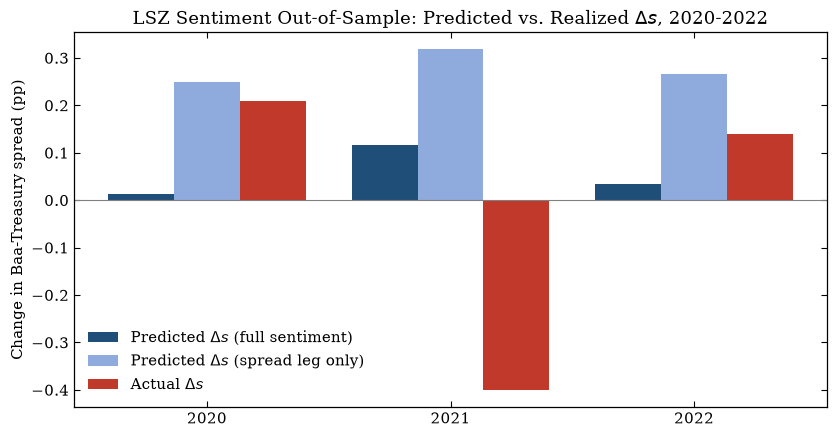

In [5]:
ps.set_paper_style()
fig, ax = plt.subplots(figsize=(8.5, 4.5))
x = np.arange(len(covid_years))
w = 0.27
ax.bar(
    x - w,
    scorecard["pred_full"],
    w,
    label=r"Predicted $\Delta s$ (full sentiment)",
    color="#1f4e79",
)
ax.bar(
    x,
    scorecard["pred_spread_only"],
    w,
    label=r"Predicted $\Delta s$ (spread leg only)",
    color="#8faadc",
)
ax.bar(
    x + w,
    scorecard["actual_dS"],
    w,
    label=r"Actual $\Delta s$",
    color=ps.HIGHLIGHT_COLOR,
)
ax.axhline(0, color="grey", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels([str(y) for y in covid_years])
ax.set_ylabel("Change in Baa-Treasury spread (pp)")
ax.set_title(
    "LSZ Sentiment Out-of-Sample: Predicted vs. Realized " r"$\Delta s$, 2020-2022"
)
ps.style_axes(ax)
ax.legend()
fig.tight_layout()

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(OUTPUT_DIR / "case_study_covid_oos.pdf")
plt.show()

## 4. What We Can and Cannot Conclude

Four honest caveats bound the reading above:

1. **The splice is not seamless.** The froth values in the COVID window come
   from the FISD reconstruction, whose construction (Moody's-rated
   denominator, coverage starting in the early 1980s) differs from the
   pre-2009 transcribed series the first stage was largely estimated on. The
   ingredient we feed the model out of sample is measured a little differently
   from the one it learned on.
2. **Three years is illustrative, not inferential.** A direction check on
   2020-2022 cannot distinguish skill from luck; it can only show which way the
   signal leaned.
3. **Generated-regressor uncertainty.** The prediction plugs in first-stage
   fitted coefficients; the standard two-step "plug-in" procedure used here
   does not propagate their sampling error, so any apparent precision is
   overstated.
4. **The first stage is held fixed at 1929-2015.** This is a true out-of-sample
   application; re-fitting through the window would change the coefficients and
   is a different (in-sample) exercise.

## Summary

We re-fit the LSZ sentiment first stage on 1929-2015, confirm that the post-2008 FISD/WRDS reconstruction now extends the
high-yield share into the COVID window, and use the fixed historical fit to
form an out-of-sample prediction of the 2020-2022 spread changes. The scorecard
in Section 3 reports the realized hit rate for the full-sentiment signal and
for the spread-only leg — both correct in 2 of 3 years, with the froth term
visibly shrinking the predicted move without changing which years hit or miss
— and the chart shows the predictions against reality. Section 4 lays out why
that record should be read cautiously: the froth-series splice, the
three-year sample, and the generated-regressor uncertainty baked into the
underlying coefficients. With only three years and a spliced froth series,
the result is an honest directional probe rather than a formal test.